# Exploração GTFS - SPTrans

- https://www.sptrans.com.br/desenvolvedores/ 

- *General Transit Feed Specification*

- https://gtfs.org/documentation/overview/

<img src="../images/MER-GTFS-SPTrans.png" alt="Modelo Entidade-Relacionamento do GTFS da SPTrans" width="100%"/>

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path

In [ ]:
DATA_PATH = Path('data/raw/gtfs/')

In [21]:
arquivos_gtfs = [
    'agency',
    'calendar',
    'fare_attributes',
    'fare_rules',
    'frequencies',
    'routes',
    'shapes',
    'stop_times',
    'stops',
    'trips'
]

gtfs = {}
for arquivo in arquivos_gtfs:
    caminho = DATA_PATH / f'{arquivo}.txt'
    gtfs[arquivo] = pd.read_csv(caminho)
    n_linhas, n_colunas = gtfs[arquivo].shape
    print(f'{arquivo:<20} {n_linhas:>10,} linhas | {n_colunas} colunas')

agency                        1 linhas | 5 colunas
calendar                      6 linhas | 10 colunas
fare_attributes               6 linhas | 6 colunas
fare_rules                5,379 linhas | 5 colunas
frequencies              40,146 linhas | 4 colunas
routes                    1,348 linhas | 7 colunas
shapes                1,134,502 linhas | 5 colunas
stop_times               98,434 linhas | 5 colunas
stops                    22,103 linhas | 5 colunas
trips                     2,254 linhas | 6 colunas


### Agency

In [49]:
print(gtfs['agency'])

   agency_id agency_name                                agency_url  \
0          1     SPTRANS  http://www.sptrans.com.br/?versao=080326   

     agency_timezone agency_lang  
0  America/Sao_Paulo          pt  


### Calendar

In [27]:
print(gtfs['calendar'])

  service_id  monday  tuesday  wednesday  thursday  friday  saturday  sunday  \
0        USD       1        1          1         1       1         1       1   
1        U__       1        1          1         1       1         0       0   
2        US_       1        1          1         1       1         1       0   
3        _SD       0        0          0         0       0         1       1   
4        __D       0        0          0         0       0         0       1   
5        _S_       0        0          0         0       0         1       0   

   start_date  end_date  
0    20231001  20261001  
1    20231001  20261001  
2    20231001  20261001  
3    20231001  20261001  
4    20231001  20261001  
5    20231001  20261001  


#### service_id
- USD: opera todos os dias
- U__: opera somente nos dias úteis
- US_: opera de segunda a sábado
- _SD: opera somente aos sábados e domingos
- __D: opera somente aos domingos
- _S_: opera somente aos sábados

### Routes

In [32]:
print(gtfs['routes'].head())

  route_id  agency_id route_short_name  \
0  1012-10          1          1012-10   
1  1012-21          1          1012-21   
2  1014-10          1          1014-10   
3  1015-10          1          1015-10   
4  1016-10          1          1016-10   

                             route_long_name  route_type route_color  \
0        Term. Jd. Britania - Jd. Monte Belo           3      509E2F   
1           Term. Jd. Britânia - Jd. Rosinha           3      509E2F   
2                    Cptm Perus - Morro Doce           3      509E2F   
3  Term. Jd. Britânia - Chác. Maria Trindade           3      509E2F   
4         Cem. Do Horto - Shop. Center Norte           3      002F6C   

  route_text_color  
0           FFFFFF  
1           FFFFFF  
2           FFFFFF  
3           FFFFFF  
4           FFFFFF  


In [36]:
print(gtfs['routes']['route_type'].value_counts())

route_type
3    1335
2       7
1       6
Name: count, dtype: int64


Referência: https://gtfs.org/documentation/schedule/reference/

route_type:
1 - Metrô
2 - Trem
**3 - Ônibus**

### Stops

In [48]:
print(gtfs['stops'].head())

   stop_id      stop_name stop_desc   stop_lat   stop_lon
0    18848       Clínicas       NaN -23.554022 -46.671108
1    18849  Vila Madalena       NaN -23.546498 -46.691141
2    18850     Consolação       NaN -23.558094 -46.660205
3    18851      Conceição       NaN -23.635039 -46.641239
4    18852      Jabaquara       NaN -23.646033 -46.641028


In [51]:
s_linhas, s_colunas = gtfs['stops'].shape
print(f' Linhas/Estações: {s_linhas:,} | Colunas: {s_colunas}')

 Linhas/Estações: 22,103 | Colunas: 5


In [42]:
# valores nulos
print(gtfs['stops'].isnull().sum())

stop_id         0
stop_name       0
stop_desc    1419
stop_lat        0
stop_lon        0
dtype: int64


In [45]:
stops = gtfs['stops']
print(f'Latitude:  {stops.stop_lat.min():.4f} (sul) a {stops.stop_lat.max():.4f} (norte)')
print(f'Longitude: {stops.stop_lon.min():.4f} (oeste) a {stops.stop_lon.max():.4f} (leste)')

Latitude:  -23.9111 (sul) a -23.1956 (norte)
Longitude: -46.9839 (oeste) a -46.1849 (leste)


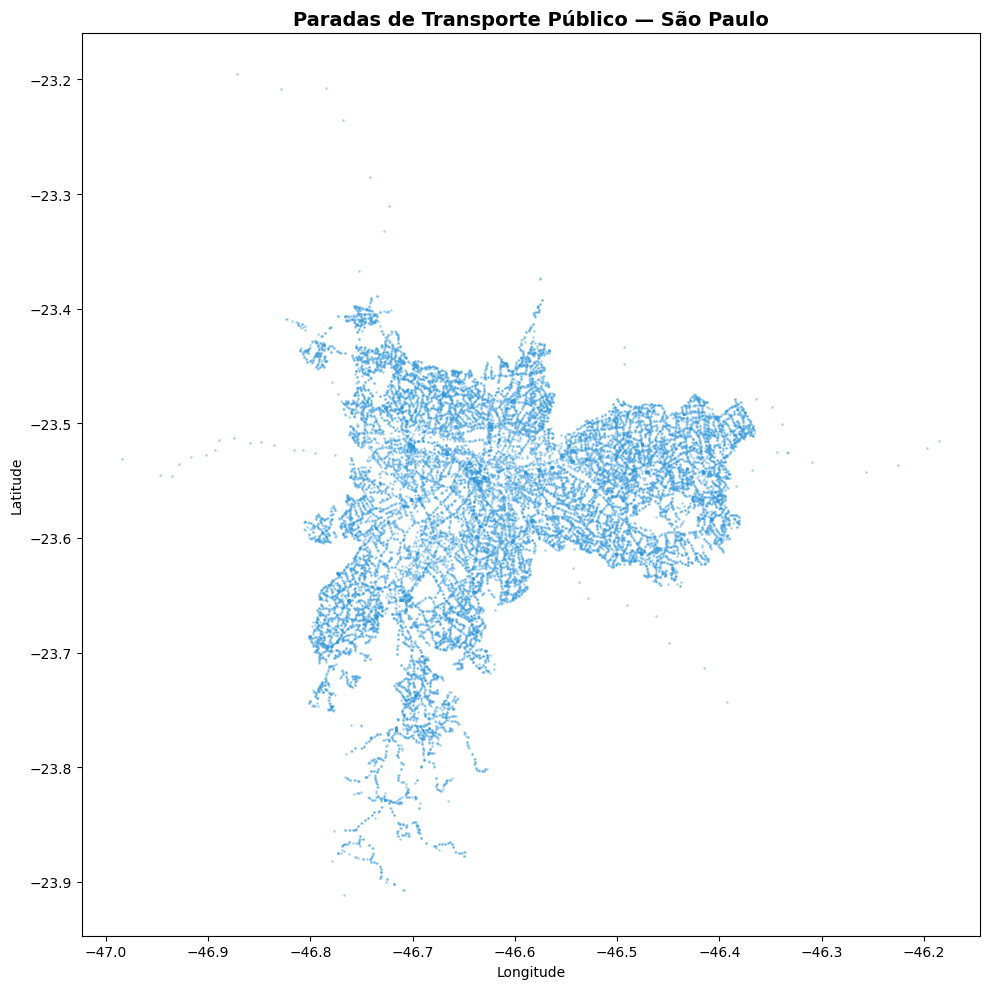

In [ ]:
stops = gtfs['stops']

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    stops['stop_lon'],   # eixo X = longitude
    stops['stop_lat'],   # eixo Y = latitude
    s=1,
    alpha=0.3,
    color='#3498db'
)

ax.set_title('Paradas / Estações'), fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

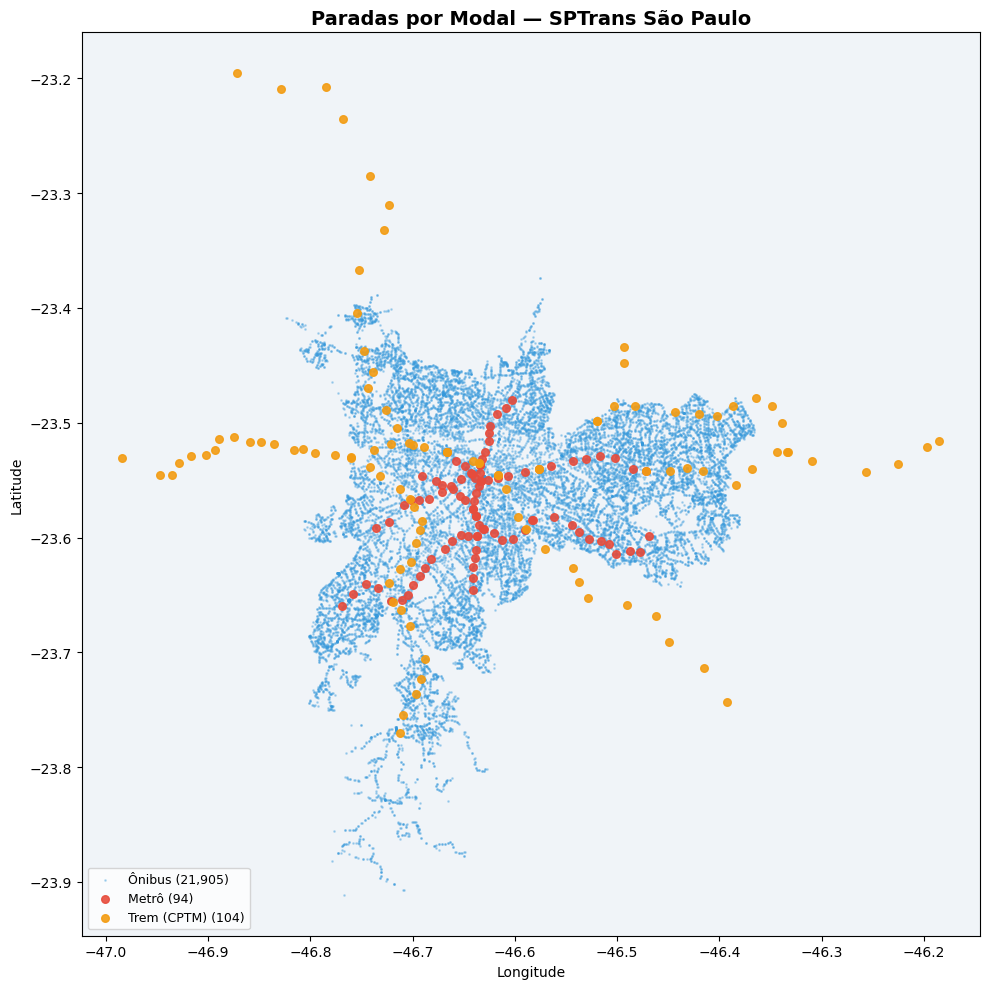

In [55]:
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']

# Passo 1: Pegar combinações únicas de (stop_id, trip_id) do stop_times
# drop_duplicates() remove repetições — só precisamos saber QUAIS trips
# passam em QUAIS paradas, não quantas vezes
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()

# Passo 2: Adicionar route_id (vem de trips)
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')

# Passo 3: Adicionar route_type (vem de routes)
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')

# Passo 4: Para cada parada, pegar o route_type predominante
# Uma parada pode ter ônibus E metrô passando. Usamos first() como simplificação.
# groupby('stop_id') agrupa todas as linhas com mesmo stop_id
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()

# Passo 5: Juntar de volta com stops pra ter as coordenadas
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')

# --- PLOTAR ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#f0f4f8')  # fundo cinza claro pra destacar os pontos

# Definir cores e nomes para cada modal
cores = {3: '#3498db', 1: '#e74c3c', 2: '#f39c12'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

# Plotar cada modal separadamente pra controlar tamanho e legenda
# Ordem importa: ônibus primeiro (fica no fundo), metrô/trem por cima
for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,       # metrô/trem maiores pra serem visíveis
        alpha=0.3 if route_type == 3 else 0.9, # ônibus mais transparente
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=2 if route_type == 3 else 3     # zorder controla quem fica "por cima"
    )

ax.set_title('Paradas por Modal — SPTrans São Paulo', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1)

plt.tight_layout()
plt.show()

In [ ]:
# pip install geopandas

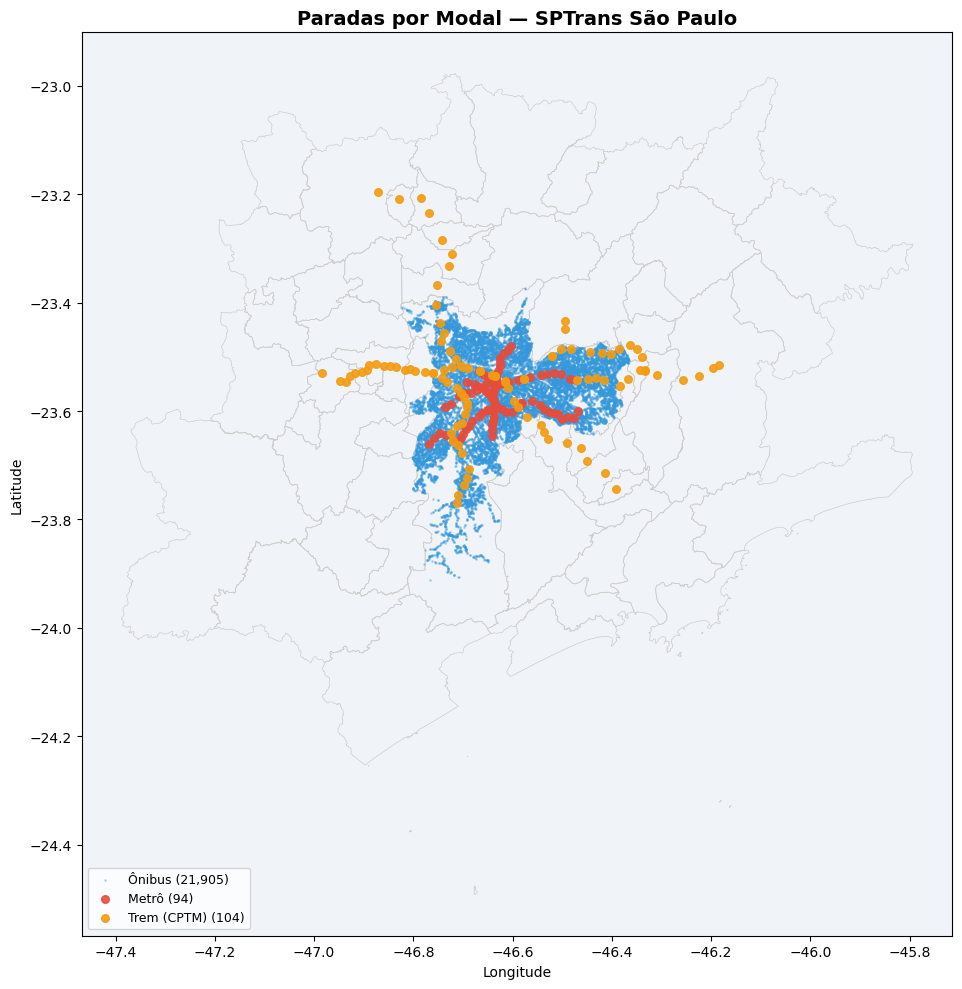

In [72]:
import geopandas as gpd
stops = gtfs['stops']
stop_times = gtfs['stop_times']
trips = gtfs['trips']
routes = gtfs['routes']


# Passo 1: Pegar combinações únicas de (stop_id, trip_id) do stop_times
# drop_duplicates() remove repetições — só precisamos saber QUAIS trips
# passam em QUAIS paradas, não quantas vezes
stop_trip = stop_times[['stop_id', 'trip_id']].drop_duplicates()

# Passo 2: Adicionar route_id (vem de trips)
stop_route = stop_trip.merge(trips[['trip_id', 'route_id']], on='trip_id')

# Passo 3: Adicionar route_type (vem de routes)
stop_route = stop_route.merge(routes[['route_id', 'route_type']], on='route_id')

# Passo 4: Para cada parada, pegar o route_type predominante
# Uma parada pode ter ônibus E metrô passando. Usamos first() como simplificação.
# groupby('stop_id') agrupa todas as linhas com mesmo stop_id
stop_modal = stop_route.groupby('stop_id')['route_type'].first().reset_index()

# Passo 5: Juntar de volta com stops pra ter as coordenadas
stops_com_modal = stops.merge(stop_modal, on='stop_id', how='left')

# --- CARREGAR LIMITES MUNICIPAIS ---
# Shapefile do IBGE com os contornos de todos os municípios de SP.
# GeoPandas lê shapefiles com gpd.read_file() e retorna um GeoDataFrame,
# que é um DataFrame do Pandas com uma coluna especial "geometry"
# contendo as formas geográficas (polígonos dos municípios).
municipios = gpd.read_file('data/raw/ibge/SP_Municipios_2022.shp')

# Filtrar apenas a Região Metropolitana de São Paulo (RMSP)
# Usamos os limites das paradas pra recortar o mapa automaticamente.
# Uma margem de 0.05 graus (~5km) evita que o mapa fique "colado" nas bordas.
margem = 0.05
lon_min = stops_com_modal['stop_lon'].min() - margem
lon_max = stops_com_modal['stop_lon'].max() + margem
lat_min = stops_com_modal['stop_lat'].min() - margem
lat_max = stops_com_modal['stop_lat'].max() + margem

# cx (clip by extent) recorta os municípios que caem dentro dessa "caixa"
municipios_recorte = municipios.cx[lon_min:lon_max, lat_min:lat_max]

# --- PLOTAR ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#f0f4f8')

# Plotar contornos dos municípios PRIMEIRO (ficam no fundo)
# facecolor='none' = sem preenchimento, só a borda
# edgecolor = cor da linha de contorno
# linewidth = espessura da linha
municipios_recorte.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#cccccc',
    linewidth=0.5,
    zorder=1
)

# Plotar paradas por cima dos limites municipais
cores = {3: '#3498db', 1: '#e74c3c', 2: '#f39c12'}
nomes = {3: 'Ônibus', 1: 'Metrô', 2: 'Trem (CPTM)'}

for route_type in [3, 1, 2]:
    mask = stops_com_modal['route_type'] == route_type
    qtd = mask.sum()
    ax.scatter(
        stops_com_modal.loc[mask, 'stop_lon'],
        stops_com_modal.loc[mask, 'stop_lat'],
        s=1 if route_type == 3 else 30,
        alpha=0.3 if route_type == 3 else 0.9,
        color=cores[route_type],
        label=f"{nomes[route_type]} ({qtd:,})",
        zorder=2 if route_type == 3 else 3
    )

ax.set_title('Paradas por Modal — SPTrans São Paulo', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1)

plt.tight_layout()
plt.show()